In [1]:
import pandas as pd
df = pd.read_excel('Telco_customer_churn.xlsx')
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [2]:
df.shape

(7043, 33)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [4]:
df['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 40)

## 1. Null Check

In [6]:
null_summary = df.isnull().sum()
null_summary[null_summary > 0]

Churn Reason    5174
dtype: int64

In [7]:
# Total Charges is stored as object — find non-numeric entries
bad_tc = df[pd.to_numeric(df['Total Charges'], errors='coerce').isna()]
print(f"Non-numeric 'Total Charges' rows: {len(bad_tc)}")
bad_tc[['CustomerID', 'Tenure Months', 'Monthly Charges', 'Total Charges']]

Non-numeric 'Total Charges' rows: 11


,CustomerID,Tenure Months,Monthly Charges,Total Charges
2234,4472-LVYGI,0,52.55,
2438,3115-CZMZD,0,20.25,
2568,5709-LVOEQ,0,80.85,
2667,4367-NUYAO,0,25.75,
2856,1371-DWPAZ,0,56.05,
4331,7644-OMVMY,0,19.85,
4687,3213-VVOLG,0,25.35,
5104,2520-SGTTA,0,20.00,
5719,2923-ARZLG,0,19.70,
6772,4075-WKNIU,0,73.35,


In [8]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce').fillna(0)
df['Total Charges'].dtype, df['Total Charges'].isnull().sum()

(dtype('float64'), np.int64(0))

## 2. Duplicate Check

In [9]:
print("Full-row duplicates:", df.duplicated().sum())
print("Duplicate CustomerIDs:", df['CustomerID'].duplicated().sum())

Full-row duplicates: 0
Duplicate CustomerIDs: 0


## 3. Visualizations


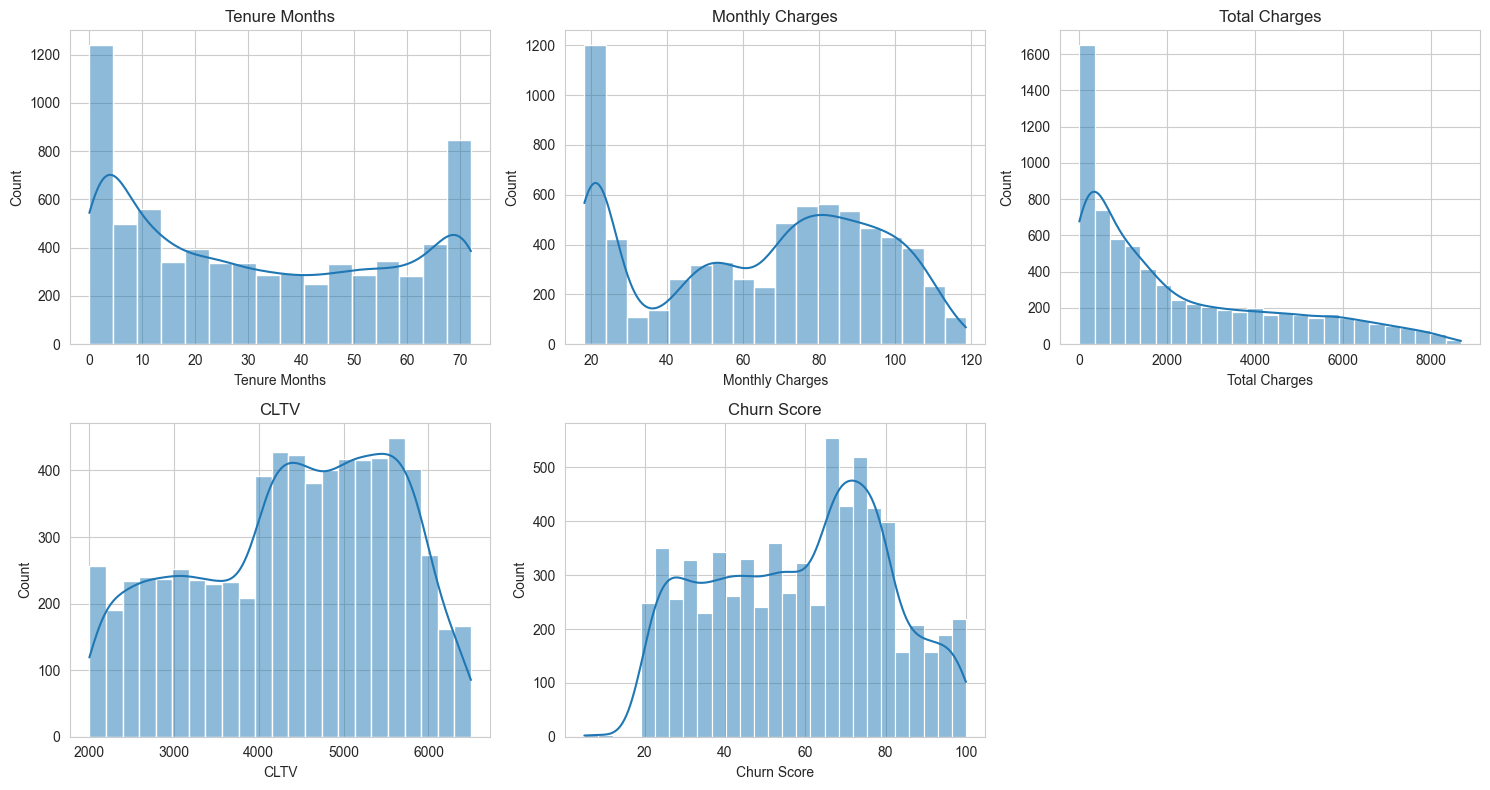

In [10]:
num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Churn Score']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

C:\Users\Userr\AppData\Local\Temp\ipykernel_11660\2389326240.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn Label', palette='Set2')


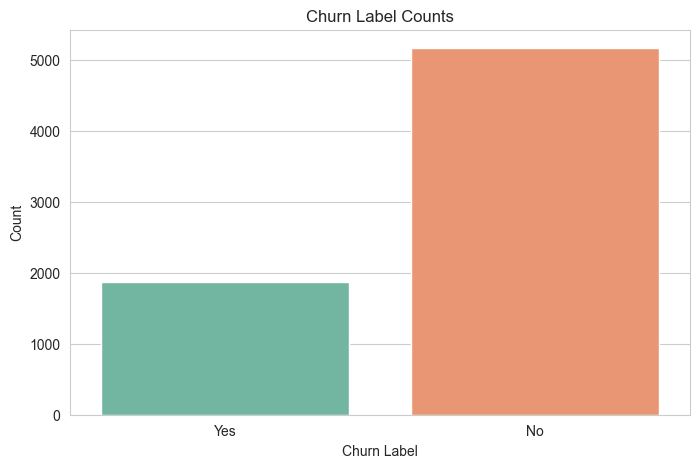

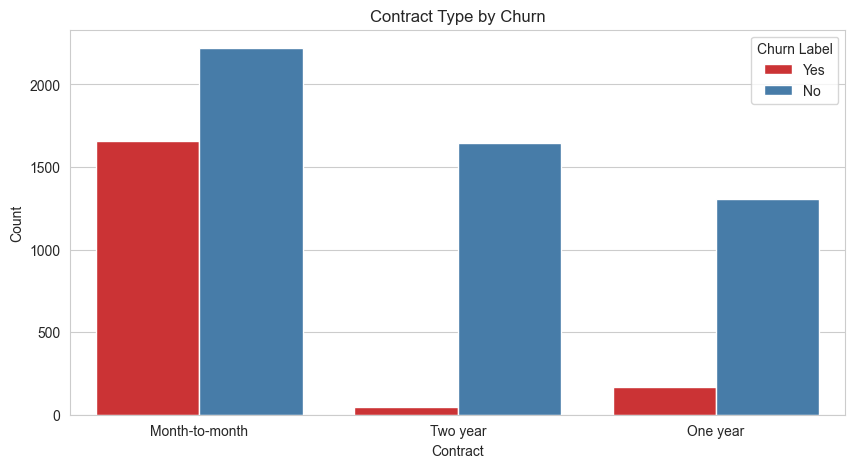

In [11]:
# churn label count
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Churn Label', palette='Set2')
plt.title('Churn Label Counts')
plt.xlabel('Churn Label')
plt.ylabel('Count')
plt.show()

# contract type by churn
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Contract', hue='Churn Label', palette='Set1')
plt.title('Contract Type by Churn')
plt.xlabel('Contract')
plt.ylabel('Count')
plt.legend(title='Churn Label')
plt.show()



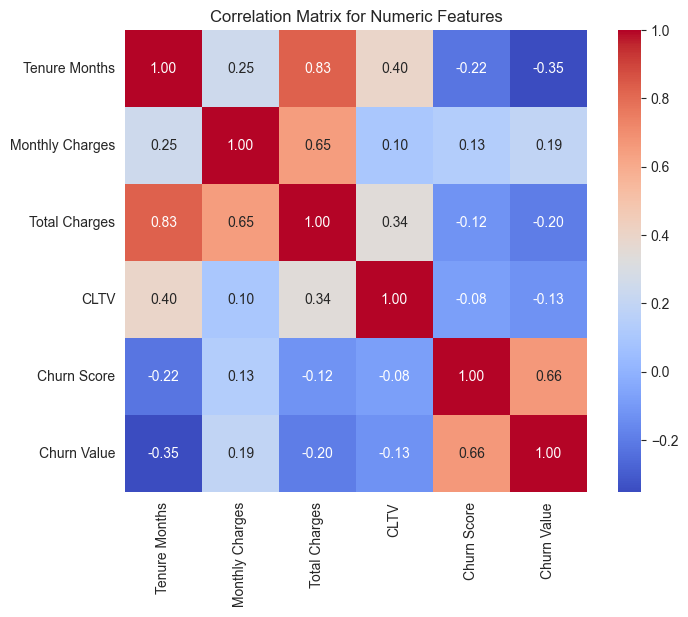

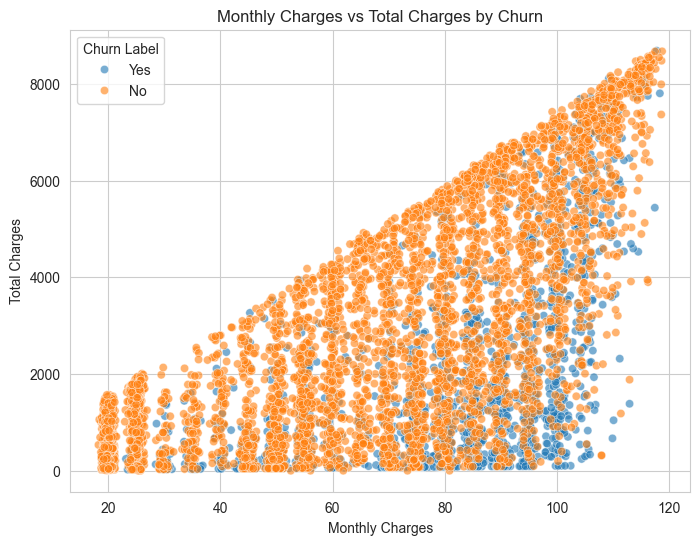

C:\Users\Userr\AppData\Local\Temp\ipykernel_11660\1137289759.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn Label', y='Monthly Charges', palette='Pastel1')


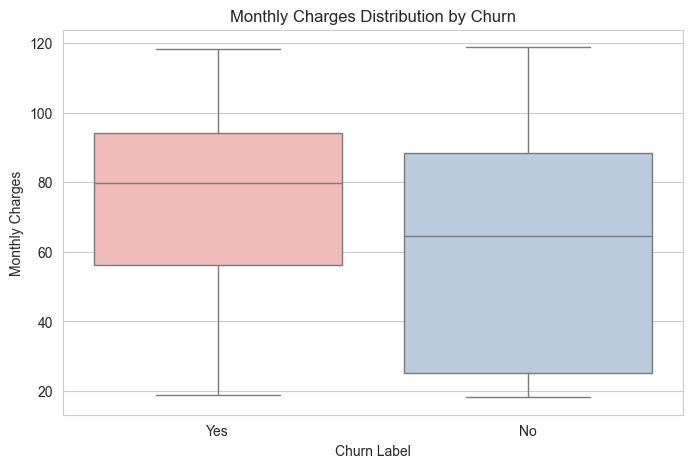

In [12]:
# correlation heatmap for numeric features
num_features = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Churn Score', 'Churn Value']
corr = df[num_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Matrix for Numeric Features')
plt.show()

# scatter plot of charges colored by churn
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Monthly Charges', y='Total Charges', hue='Churn Label', alpha=0.6)
plt.title('Monthly Charges vs Total Charges by Churn')
plt.xlabel('Monthly Charges')
plt.ylabel('Total Charges')
plt.show()

# monthly charges distribution by churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn Label', y='Monthly Charges', palette='Pastel1')
plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Churn Label')
plt.ylabel('Monthly Charges')
plt.show()

## 4. Dropping Irrelevant / Leakage / Redundant Columns

In [13]:
drop_cols = [
    'CustomerID',       # unique identifier, no predictive value
    'Count',            # constant = 1 for all rows
    'Country', 'State', # constant ('United States', 'California') for all rows
    'Lat Long',         # redundant with Latitude/Longitude
    'Churn Label',      # duplicate of Churn Value (target)
    'Churn Score',      # leakage: post-hoc churn propensity score
    'Churn Reason',     # leakage: only exists for churned customers
    'CLTV',             # often computed post-hoc; potential leakage
]
df = df.drop(columns=drop_cols)
df.shape

(7043, 24)

## 5. Encoding Categorical Columns

In [14]:
target = 'Churn Value'

# Binary Yes/No (and similar 2-value) columns -> 0/1 label encoding
binary_cols = [c for c in df.columns
                if df[c].dtype == object and df[c].nunique() == 2 and c != target]
for c in binary_cols:
    df[c] = df[c].map({v: i for i, v in enumerate(sorted(df[c].unique()))})

print("Binary-encoded:", binary_cols)

Binary-encoded: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Paperless Billing']


In [15]:
# Multi-category columns (3+ unique values) -> one-hot encoding
multi_cols = [c for c in df.columns
               if df[c].dtype == object and df[c].nunique() > 2 and c not in ('City',)]
print("One-hot encoded:", multi_cols)

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)
df.shape

One-hot encoded: ['Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Payment Method']


(7043, 35)

In [16]:
# High-cardinality 'City' (1100+ values) -> frequency encoding to avoid huge dimensionality
print("Unique cities:", df['City'].nunique())
df['City'] = df['City'].map(df['City'].value_counts())
df.head()

Unique cities: 1129


,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Paperless Billing,Monthly Charges,Total Charges,Churn Value,Multiple Lines_No phone service,Multiple Lines_Yes,Internet Service_Fiber optic,Internet Service_No,Online Security_No internet service,Online Security_Yes,Online Backup_No internet service,Online Backup_Yes,Device Protection_No internet service,Device Protection_Yes,Tech Support_No internet service,Tech Support_Yes,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,305,90003,33.964131,-118.272783,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
1,305,90005,34.059281,-118.307420,0,0,0,1,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,305,90006,34.048013,-118.293953,0,0,0,1,8,1,1,99.65,820.50,1,False,True,True,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,True,False
3,305,90010,34.062125,-118.315709,0,0,1,1,28,1,1,104.80,3046.05,1,False,True,True,False,False,False,False,False,False,True,False,True,False,True,False,True,False,False,False,True,False
4,305,90015,34.039224,-118.266293,1,0,0,1,49,1,1,103.70,5036.30,1,False,True,True,False,False,False,False,True,False,True,False,False,False,True,False,True,False,False,False,False,False


## 6. Train/Test Split (80/20)

In [17]:
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train churn rate:", y_train.mean().round(3), "| Test churn rate:", y_test.mean().round(3))

Train: (5634, 34) Test: (1409, 34)
Train churn rate: 0.265 | Test churn rate: 0.265


In [18]:
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
print("Saved: X_train.csv, X_test.csv, y_train.csv, y_test.csv")

Saved: X_train.csv, X_test.csv, y_train.csv, y_test.csv


## Phase 3

In [19]:
import os
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from xgboost import XGBClassifier

sns.set_style("whitegrid")
RANDOM_STATE = 42


## 2. Load Data


In [20]:
files = ["X_train.csv", "X_test.csv", "y_train.csv", "y_test.csv"]

if all(os.path.exists(f) for f in files):
    X_train, X_test = pd.read_csv("X_train.csv"), pd.read_csv("X_test.csv")
    y_train, y_test = pd.read_csv("y_train.csv").iloc[:, 0], pd.read_csv("y_test.csv").iloc[:, 0]
else:
    df = pd.read_excel("Telco_customer_churn.xlsx")

    df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce").fillna(0)

    df = df.drop(columns=["CustomerID", "Count", "Country", "State", "Zip Code", "Lat Long",
                           "Churn Reason", "Churn Score", "CLTV", "Churn Label"])

    y = df.pop("Churn Value").astype(int)

    df["City"] = df["City"].map(df["City"].value_counts(normalize=True))  # frequency encode

    binary_cols = ["Gender", "Senior Citizen", "Partner", "Dependents", "Phone Service", "Paperless Billing"]
    df[binary_cols] = df[binary_cols].apply(lambda c: c.map({"Yes": 1, "No": 0, "Male": 1, "Female": 0}))

    multi_cols = ["Multiple Lines", "Internet Service", "Online Security", "Online Backup",
                  "Device Protection", "Tech Support", "Streaming TV", "Streaming Movies",
                  "Contract", "Payment Method"]
    df = pd.get_dummies(df, columns=multi_cols, drop_first=True)
    bool_cols = df.select_dtypes(bool).columns
    df[bool_cols] = df[bool_cols].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        df, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    for name, obj in zip(files, [X_train, X_test, y_train, y_test]):
        obj.to_csv(name, index=False)

print(f"Train: {X_train.shape}   Test: {X_test.shape}   Churn rate: {y_train.mean():.1%}")


Train: (5634, 34)   Test: (1409, 34)   Churn rate: 26.5%


## 3. Train Models

Each model below uses `class_weight="balanced"` (or XGBoost's equivalent `scale_pos_weight`) so the ~26.5% churn rate doesn't get ignored. The `record_model` helper just fits, predicts, prints F1/AUC-ROC, and stores the score — it avoids repeating those same four lines under every model.

In [21]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
results = []

def record_model(name, model):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    f1, auc = f1_score(y_test, pred), roc_auc_score(y_test, proba)
    results.append({"Model": name, "F1": f1, "AUC-ROC": auc})
    print(f"{name:<20} F1: {f1:.3f}   AUC-ROC: {auc:.3f}")
    return model


### 3a. Logistic Regression

In [22]:
log_reg = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
)
log_reg = record_model("Logistic Regression", log_reg)



Logistic Regression  F1: 0.624   AUC-ROC: 0.848


### 3b. Random Forest

In [25]:
# Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)
rf = record_model("Random Forest", rf)

Random Forest        F1: 0.609   AUC-ROC: 0.843


### 3c. XGBoost

In [26]:
xgb = XGBClassifier(
    n_estimators=300, scale_pos_weight=scale_pos_weight,
    eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1
)
xgb = record_model("XGBoost", xgb)


XGBoost              F1: 0.568   AUC-ROC: 0.819


### 3d. Comparison

In [27]:
results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
results_df

,Model,F1,AUC-ROC
0,Logistic Regression,0.623679,0.847617
1,Random Forest,0.613139,0.842201
2,Random Forest,0.609013,0.843172
3,XGBoost,0.567742,0.818652


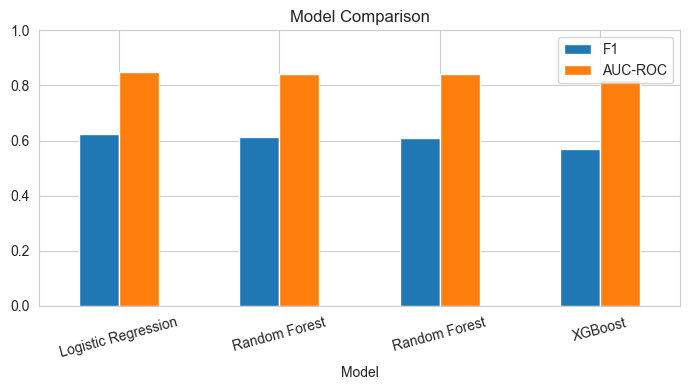

In [28]:
results_df.plot(x="Model", y=["F1", "AUC-ROC"], kind="bar", figsize=(7, 4), ylim=(0, 1))
plt.title("Model Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 4. Tune the Best Model

Random Forest is tuned with `RandomizedSearchCV` (5-fold cross-validation, optimizing F1) since tree-based models usually have the most room to improve through tuning.

In [29]:
param_grid = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [8, 12, 16, None],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}

search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_grid, n_iter=15, scoring="f1", cv=5,
    random_state=RANDOM_STATE, n_jobs=-1,
)
search.fit(X_train, y_train)

best_model = search.best_estimator_
print("Best params:", search.best_params_)


Best params: {'n_estimators': 300, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 12}


## 5. Final Evaluation

              precision    recall  f1-score   support

    No Churn       0.91      0.77      0.83      1035
       Churn       0.55      0.78      0.64       374

    accuracy                           0.77      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.77      0.78      1409

F1: 0.642   AUC-ROC: 0.852


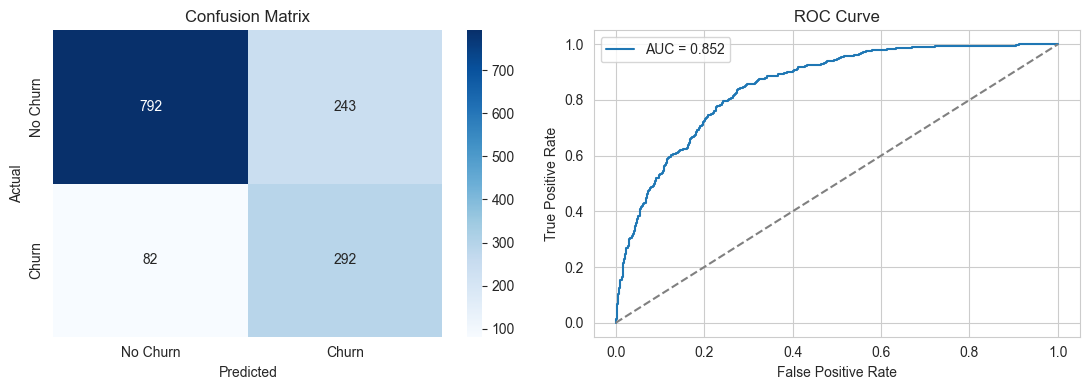

In [30]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))
print(f"F1: {f1_score(y_test, y_pred):.3f}   AUC-ROC: {roc_auc_score(y_test, y_proba):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"], ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Feature Importance

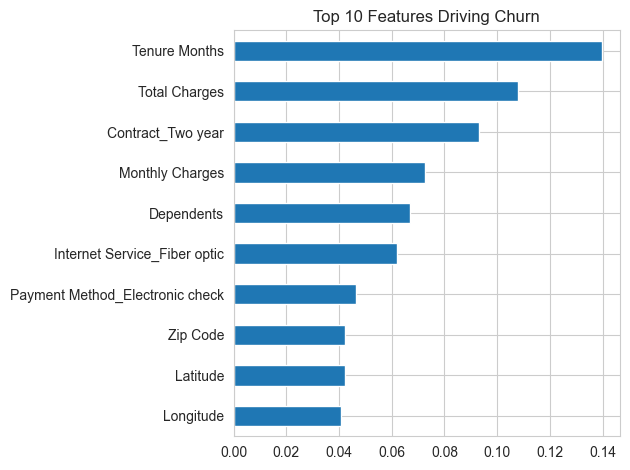

In [31]:
importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(10).plot(kind="barh")
plt.title("Top 10 Features Driving Churn")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Save Model

In [32]:
joblib.dump(best_model, "churn_model_final.pkl")
print("Saved churn_model_final.pkl")

Saved churn_model_final.pkl
